In [83]:
import sys
sys.path.append("..")
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from numbers import Number
import numpy as np
import scipy as scipy

In [88]:
# 4 exc
def prep_psi_0(qc: QuantumCircuit):
    qc.cx(32,0)
    qc.cx(32,10)
    qc.cx(32,26)
    qc.cx(32,17)
    return qc


def prep_psi_0_by_0(qc: QuantumCircuit):
    qc.cx(32,0,ctrl_state="0")
    qc.cx(32,10,ctrl_state="0")
    qc.cx(32,26,ctrl_state="0")
    qc.cx(32,17,ctrl_state="0")
    return qc

In [89]:
from qiskit_aer import StatevectorSimulator
from qiskit_aer.primitives import SamplerV2

# sv = StatevectorSimulator()
sampler = SamplerV2(options={"backend_options": {"method": "matrix_product_state"}})
qc = QuantumCircuit(33)
qc.h(32)
qc = prep_psi_0(qc)
qc.measure_all()

job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'000000000000000000000000000000000': 511,
 '100000100000000100000010000000001': 513}

In [90]:
qc = QuantumCircuit(33)
qc.h(32)
qc = prep_psi_0(qc)
qc = prep_psi_0_by_0(qc)
qc.measure_all()
job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'000000100000000100000010000000001': 503,
 '100000100000000100000010000000001': 521}

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService

service=QiskitRuntimeService(name='enablement-work')

backend= service.backend('ibm_torino')

In [110]:
qubit_subset = [64,63,73,82,83,84,85,86,74,67,66,68,69,56,50,49,48,47,36,29,28,27,26,25,35,44,45,43,42,54,61,62,46,65,55]
# qubit_subset=[42,43,44,45,47,35,25,26,27,28,46,29,36,48,49,50,54,61,62,63,64,66,67,68,69,56,73,82,83,84,65,85,86,74]


cm = backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}




In [111]:
edge_list = edge_list-{(32,34),(33,34),(0,33),(10,33),(26,32),(17,32)}
edge_list

{(0, 1),
 (1, 2),
 (1, 31),
 (2, 3),
 (3, 4),
 (4, 5),
 (5, 6),
 (6, 7),
 (7, 8),
 (8, 9),
 (9, 10),
 (9, 11),
 (11, 12),
 (12, 13),
 (13, 14),
 (14, 15),
 (15, 16),
 (16, 17),
 (16, 18),
 (18, 19),
 (19, 20),
 (20, 21),
 (21, 22),
 (22, 23),
 (23, 24),
 (24, 25),
 (25, 26),
 (25, 27),
 (27, 28),
 (28, 29),
 (29, 30),
 (30, 31)}

In [112]:
dict = {i:val for i, val in enumerate(qubit_subset)}
dict

{0: 64,
 1: 63,
 2: 73,
 3: 82,
 4: 83,
 5: 84,
 6: 85,
 7: 86,
 8: 74,
 9: 67,
 10: 66,
 11: 68,
 12: 69,
 13: 56,
 14: 50,
 15: 49,
 16: 48,
 17: 47,
 18: 36,
 19: 29,
 20: 28,
 21: 27,
 22: 26,
 23: 25,
 24: 35,
 25: 44,
 26: 45,
 27: 43,
 28: 42,
 29: 54,
 30: 61,
 31: 62,
 32: 46,
 33: 65,
 34: 55}

In [113]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.synthesis import SuzukiTrotter, LieTrotter

t_steps = 10
step_size=12
num_data_qubits=32
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi /step_size



def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)     
    return H.chop()


H = Heisenberg(1, num_data_qubits, edge_list)

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(num_data_qubits)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(num_data_qubits).compose(qc_temp)
reverse_time_evol = time_evol.reverse_ops()

#time_evol=PauliEvolutionGate(H,time=delta_t,synthesis=synth)
real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * num_data_qubits, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * num_data_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(33)
        qc.h(32)
        qc = prep_psi_0(qc)
        for p in range(n):
            qc.append(time_evol, list(range(num_data_qubits)))
        qc = prep_psi_0_by_0(qc)
        for q in range(m):
            qc.append(time_evol, list(range(num_data_qubits)))

        circuits[i][j] = qc.copy()

#init_layout = qubit_subset + [55]  # ancilla at qubit 55 on torino # ancilla at 51 would be sticking out
init_layout = [64,63,73,82,83,84,85,86,74,67,66,68,69,56,50,49,48,47,36,29,28,27,26,25,35,44,45,43,42,54,61,62,55]
pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3, initial_layout=init_layout,
)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

print(
    f"Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)
print(
    f"Min circuit depth:{min([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)
print(
    f"Mean circuit depth:{np.mean([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)

Max circuit depth:136
Min circuit depth:23
Mean circuit depth:88.56


In [115]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    # make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T
    print(len(truncated_eigvals))
    return truncated_eigvecs


def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)+1):
        epsilon = threshold_slope
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        # solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps
        B = V_eps.conj().T @ S_temp @ V_eps
        E, c = scipy.linalg.eig(a=A, b=B)
        idx = E.argsort()[::-1]
        eigvals = E[idx]
        eigvecs = c[:, idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:, -1])
        print(min(eigvals))

    return GSEs, ground_states, V_eps

## Run on (a noisy) simulator for comparison

In [116]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit import transpile
from qiskit_aer.primitives import EstimatorV2
# from qiskit_ibm_runtime import EstimatorV2
from qiskit import transpile
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from tqdm.notebook import tqdm


circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde_sim_noisy = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy= np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / step_size
num_shots = 800000

H = Heisenberg(1, num_data_qubits, edge_list)

basis_gates = backend.basis_gates


# initialize noisy simulator

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state"},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)

#time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

real_obs_H = SparsePauliOp("X", 1) ^ H
imag_obs_H = SparsePauliOp("Y", 1) ^ H
real_obs_S = SparsePauliOp("X", 1) ^ SparsePauliOp("I" * num_data_qubits, 1)
imag_obs_S = SparsePauliOp("Y", 1) ^ SparsePauliOp("I" * num_data_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(33)
        qc.h(32)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(num_data_qubits))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(num_data_qubits))
        circuits[i][j] = transpile(qc.copy().decompose(reps=1), basis_gates=basis_gates)



with tqdm(total=t_steps*t_steps) as pbar:
    for i in range(t_steps):
        for j in range(t_steps):
            if circuits[i][j] is not None:
                circ = circuits[i][j]
                layout = circ.layout
                obs=[real_obs_H, imag_obs_H,
                          real_obs_S, imag_obs_S]
                sim_job = simulator.run(
                [
                    (
                        circ, obs
                    )
                ]
                )
                H_tilde_sim_noisy[i, j] = (
                    sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy[i, j] = (
                    sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
                )
            else:
                circ = circuits[j][i]
                layout = circ.layout
                obs=[real_obs_H.apply_layout(layout), imag_obs_H.apply_layout(layout),
                          real_obs_S.apply_layout(layout), imag_obs_S.apply_layout(layout)]
                sim_job = simulator.run(
                [
                    (
                        circ,obs
                    )
                ]
                )
                H_tilde_sim_noisy[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
                )
            pbar.update(1)

        

  0%|          | 0/100 [00:00<?, ?it/s]

1
(15.984572121655415+0.003725436030963151j)
2
(13.68876336885783-0.011611639403797005j)
3
(13.013029158329772-0.03244911196487697j)
4
(12.602085276144356-0.03856176872786478j)
5
(12.357599886813942-0.03458459252122254j)
6
(12.158133958639247-0.03554432330433831j)
7
(12.02597228746546-0.055115831177620124j)
8
(11.895296248023802-0.0715589278498758j)
9
(11.80192388757284-0.0780825870148303j)
10
(11.727759997238511-0.07808789434230498j)


/Users/ibrahimshehzad/uds/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ibrahimshehzad/uds/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Ground state energy')

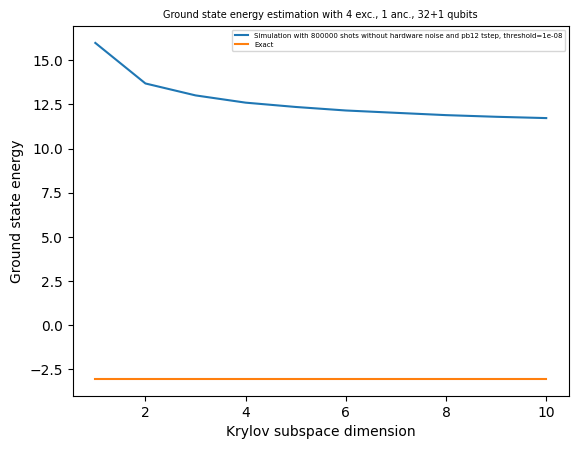

In [117]:
import matplotlib.pyplot as plt

threshold = 1e-8
GSEs_sim_noisy,g_state,_ = E_vs_D(H_tilde_sim_noisy, S_tilde_sim_noisy,threshold)

plt.plot(
    list(range(1, t_steps + 1)),
         GSEs_sim_noisy,
    label=f"Simulation with {num_shots} shots without hardware noise and pb{step_size} tstep, threshold={threshold}",
)
plt.plot(
    list(range(1, t_steps+1)),
    -3.043618282019092* np.ones(t_steps),
    label="Exact",
)

plt.title("Ground state energy estimation with 4 exc., 1 anc., 32+1 qubits", fontsize=7)
plt.legend(fontsize = 5,loc="upper right")
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")

#### Coefficients (amplitudes) of the ground state in Krylov basis

In [100]:
g_state[-1]

array([-0.08703609+0.39617871j,  0.14535936-0.08603313j,
       -0.07816908+0.60536875j, -0.40904618-0.32712603j,
       -0.06142094-0.11544463j, -0.20264527-0.13009478j,
        0.19863547-0.08721355j,  0.19291027-0.0256472j ])

## Exact diagonalisation for comparison

In [101]:
# Method from Krylov tutorial
import itertools as it
import scipy as sp
from qiskit.quantum_info import Pauli
from tqdm.notebook import tqdm


def n_particle_gs(H_op, n_qubits, n_exc):
    """
    Find the ground state of the n particle(excitation) sector
    """
    H_x = []
    for p, coeff in H_op.to_list():
        H_x.append(set([i for i, v in enumerate(Pauli(p).x) if v]))

    H_z = []
    for p, coeff in H_op.to_list():
        H_z.append(set([i for i, v in enumerate(Pauli(p).z) if v]))

    H_c = H_op.coeffs

    n_exc = n_exc
    sub_dimn = int(sp.special.comb(n_qubits, n_exc))
    print("n_exc", n_exc, ", subspace dimension", sub_dimn)

    n_particle_H = np.zeros((sub_dimn, sub_dimn), dtype=complex)

    sparse_vecs = [
        set(vec) for vec in it.combinations(range(n_qubits), r=n_exc)
    ]  # list all of the possible sets of n_exc indices of 1s in n_exc-particle states

    with tqdm(total=len(sparse_vecs)*len(sparse_vecs)) as pbar:
        for i, i_set in enumerate(sparse_vecs):
            for j, j_set in enumerate(sparse_vecs):
                if len(i_set.symmetric_difference(j_set)) <= 2:

                    for p_x, p_z, coeff in zip(H_x, H_z, H_c):

                        if i_set.symmetric_difference(j_set) == p_x:
                            sgn = ((-1j) ** len(p_x.intersection(p_z))) * (
                            (-1) ** len(i_set.intersection(p_z))
                        )
                        else:
                            sgn = 0

                        n_particle_H[i, j] += sgn * coeff
                pbar.update(1)
    n_particle_H_sparse = sp.sparse.csr_array(n_particle_H)
    eige, eigv = sp.sparse.linalg.eigsh(n_particle_H_sparse, which='SA', k=1)
    print(eige)
   # eige, eigv = np.linalg.eigh(n_particle_H)
    gs_en = eige[0]  # min(eige)
    gs_vec = eigv[:, 0]
    print("n_exc particle ground state energy: ", gs_en)
    return gs_en, gs_vec, n_particle_H, sparse_vecs

H = Heisenberg(1, num_data_qubits, edge_list)
en, state, subspace_h, sp_vec= n_particle_gs(H,num_data_qubits, 4)

n_exc 4 , subspace dimension 35960


  0%|          | 0/1293121600 [00:00<?, ?it/s]

[-3.04361828]
n_exc particle ground state energy:  -3.043618282019092
